# Setup python environment

In [17]:
%pip install pandas numpy matplotlib tensorflow scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Constants

In [18]:
FEATURE_COLS = [
    "NO2",
    "C2H5OH",
    "VOC",
    "CO",
    "Alcohol",
    "LPG",
    "Benzene",
    "Temperature",
    "Pressure",
    "Humidity",
    "Gas_Resistance",
    "Altitude",
]
FEATURE_COLS_EXTENDED = FEATURE_COLS + [f"{c}_diff" for c in FEATURE_COLS]
TARGET_COL = "smell"
SEQ_LEN = 25
SMELLS = [
    "allspice",
    "almond",
    "angelica",
    "apple",
    "asparagus",
    "avocado",
    "banana",
    "brazil_nut",
    "broccoli",
    "brussel_sprouts",
    "cabbage",
    "cashew",
    "cauliflower",
    "chamomile",
    "chervil",
    "chestnuts",
    "chives",
    "cinnamon",
    "cloves",
    "coriander",
    "cumin",
    "dill",
    "garlic",
    "ginger",
    "hazelnut",
    "kiwi",
    "lemon",
    "mandarin_orange",
    "mango",
    "mint",
    "mugwort",
    "mustard",
    "nutmeg",
    "oregano",
    "peach",
    "peanuts",
    "pear",
    "pecans",
    "pili_nut",
    "pineapple",
    "pistachios",
    "potato",
    "radish",
    "saffron",
    "star_anise",
    "strawberry",
    "sweet_potato",
    "tomato",
    "turnip",
    "walnuts",
]

# Load Data

In [19]:
import os
import pandas as pd

def add_fotd_features(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in feature_cols:
        df[col + "_diff"] = df[col].diff()
    df = df.fillna(0)
    return df


def load_dataset(base_dir: str) -> pd.DataFrame:
    dfs = []
    for folder in os.listdir(base_dir):
        if folder not in SMELLS: continue
        
        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        for file in os.listdir(folder_path):
            if not file.endswith(".csv"):
                continue
            fp = os.path.join(folder_path, file)
            df = pd.read_csv(fp)
            df[TARGET_COL] = folder
            df["sequence_id"] = file  # unique per recording
            df = add_fotd_features(df, FEATURE_COLS)
            dfs.append(df)
    if len(dfs) == 0:
        raise ValueError(f"No CSVs found under {base_dir}")
    return pd.concat(dfs, ignore_index=True)


training_data = load_dataset("../data/smellnet/offline_training")
testing_data  = load_dataset("../data/smellnet/offline_testing")

print(len(testing_data), " testing entries")
print(len(training_data), " training entries")

30007  testing entries
150711  training entries


# Neural Network

## Data preprocessing

In [20]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder


training_data["Gas_Resistance"] = np.log1p(training_data["Gas_Resistance"])
testing_data["Gas_Resistance"]  = np.log1p(testing_data["Gas_Resistance"])


label_encoder = LabelEncoder()
training_data['target_enc'] = label_encoder.fit_transform(training_data[TARGET_COL])
testing_data['target_enc']  = label_encoder.transform(testing_data[TARGET_COL])


NUM_CLASSES = len(label_encoder.classes_)


scaler = StandardScaler()
training_data_scaled = training_data.copy()
testing_data_scaled  = testing_data.copy()

training_data_scaled[FEATURE_COLS_EXTENDED] = scaler.fit_transform(training_data[FEATURE_COLS_EXTENDED])
testing_data_scaled[FEATURE_COLS_EXTENDED]  = scaler.transform(testing_data[FEATURE_COLS_EXTENDED])

## Create sequences

In [21]:
from collections import defaultdict
import numpy as np

def create_sequences_grouped(df: pd.DataFrame, feature_cols: list[str], target_col: str, seq_len: int):
    X, y = [], []

    for _, group in df.groupby("sequence_id"):
        data = group[feature_cols].values
        labels = group[target_col].values

        if len(group) < seq_len:
            continue

        for i in range(len(group) - seq_len + 1):
            # double check all the samples in a sequence are of same smell
            # if not all([l == labels[i+seq_len-1] for l in labels[i:i+seq_len]]):  
            #     print("Skipped invalid sequence")
            #     continue

            X.append(data[i:i+seq_len])
            y.append(labels[i+seq_len-1])

    return np.array(X), np.array(y)


seq_labels = (
    training_data_scaled
    .groupby("sequence_id")["target_enc"]
    .first()
)

class_to_sequences = defaultdict(list)

for seq_id, label in seq_labels.items():
    class_to_sequences[label].append(seq_id)

train_ids = []
val_ids = []

for label, seqs in class_to_sequences.items():
    seqs = np.array(seqs)
    np.random.shuffle(seqs)

    # 5 sequences for each smell
    # use one for validation so no overlap in sequence samples
    val_ids.append(seqs[0])
    train_ids.extend(seqs[1:])

train_df = training_data_scaled[training_data_scaled["sequence_id"].isin(train_ids)]
val_df = training_data_scaled[training_data_scaled["sequence_id"].isin(val_ids)]

X_train_seq, y_train_seq = create_sequences_grouped(train_df, FEATURE_COLS_EXTENDED, 'target_enc', SEQ_LEN)
X_val_seq, y_val_seq = create_sequences_grouped(val_df, FEATURE_COLS_EXTENDED, 'target_enc', SEQ_LEN)

X_test_seq,  y_test_seq  = create_sequences_grouped(testing_data_scaled,  FEATURE_COLS_EXTENDED, 'target_enc', SEQ_LEN)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (115671, 25, 24)
y_train_seq shape: (115671,)
X_test_seq shape: (28807, 25, 24)
y_test_seq shape: (28807,)


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, Model

EMBED_DIM = 128
PROJ_DIM = 64

def build_encoder():
    inp = layers.Input(shape=(SEQ_LEN, len(FEATURE_COLS_EXTENDED)))
    x = layers.Masking()(inp)
    x = layers.LSTM(128, return_sequences=False)(x)
    x = layers.Dense(EMBED_DIM)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return Model(inp, x, name="encoder")

def build_projection_head():
    inp = layers.Input(shape=(EMBED_DIM,))
    x = layers.Dense(EMBED_DIM, activation='relu')(inp)
    x = layers.Dense(PROJ_DIM)(x)
    x = layers.LayerNormalization()(x)  # optional
    x = tf.keras.layers.Lambda(lambda t: tf.nn.l2_normalize(t, axis=1))(x)
    return Model(inp, x, name="projection_head")

encoder = build_encoder()
proj_head = build_projection_head()

In [23]:
def supervised_contrastive_loss(labels, embeddings, temperature=0.1):
    """
    labels: (batch,)
    embeddings: (batch, dim) - MUST be normalized
    """
    labels = tf.reshape(labels, [-1, 1])
    
    # mask for positive pairs
    mask = tf.cast(tf.equal(labels, tf.transpose(labels)), tf.float32)

    # similarity matrix
    sim = tf.matmul(embeddings, embeddings, transpose_b=True)
    sim = sim / temperature

    # remove self-comparisons
    logits_mask = 1 - tf.eye(tf.shape(labels)[0])
    mask = mask * logits_mask

    exp_sim = tf.exp(sim) * logits_mask
    log_prob = sim - tf.math.log(tf.reduce_sum(exp_sim, axis=1, keepdims=True))

    # mean log-likelihood over positives
    mean_log_prob_pos = tf.reduce_sum(mask * log_prob, axis=1) / (
        tf.reduce_sum(mask, axis=1) + 1e-8
    )

    loss = -tf.reduce_mean(mean_log_prob_pos)
    return loss

In [24]:
BATCH_SIZE = 128
EPOCHS = 30
TEMPERATURE = 0.1

optimizer = tf.keras.optimizers.Adam(1e-3)

# simple batching
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq))
train_dataset = (
    train_dataset
    .shuffle(10000)
    .batch(BATCH_SIZE, drop_remainder=True)
)

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        h = encoder(x, training=True)
        z = proj_head(h, training=True)
        z = tf.math.l2_normalize(z, axis=1)

        loss = supervised_contrastive_loss(y, z, temperature=TEMPERATURE)

    grads = tape.gradient(loss, encoder.trainable_weights + proj_head.trainable_weights)
    optimizer.apply_gradients(zip(grads, encoder.trainable_weights + proj_head.trainable_weights))
    return loss

# training loop
for epoch in range(EPOCHS):
    losses = []
    for x_batch, y_batch in train_dataset:
        loss = train_step(x_batch, y_batch)
        losses.append(loss.numpy())

    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {np.mean(losses):.4f}")

Epoch 1/30 - loss: 2.5054
Epoch 2/30 - loss: 2.4857
Epoch 3/30 - loss: 2.4691
Epoch 4/30 - loss: 2.4550
Epoch 5/30 - loss: 2.4438
Epoch 6/30 - loss: 2.4321
Epoch 7/30 - loss: 2.4252
Epoch 8/30 - loss: 2.4195
Epoch 9/30 - loss: 2.4259
Epoch 10/30 - loss: 2.4164
Epoch 11/30 - loss: 2.4181
Epoch 12/30 - loss: 2.4154
Epoch 13/30 - loss: 2.4098
Epoch 14/30 - loss: 2.4085
Epoch 15/30 - loss: 2.4120
Epoch 16/30 - loss: 2.4069
Epoch 17/30 - loss: 2.4165
Epoch 18/30 - loss: 2.4124
Epoch 19/30 - loss: 2.4045
Epoch 20/30 - loss: 2.4087
Epoch 21/30 - loss: 2.4013
Epoch 22/30 - loss: 2.4087
Epoch 23/30 - loss: 2.4106
Epoch 24/30 - loss: 2.4073
Epoch 25/30 - loss: 2.4060
Epoch 26/30 - loss: 2.4015
Epoch 27/30 - loss: 2.4057
Epoch 28/30 - loss: 2.4089
Epoch 29/30 - loss: 2.4029
Epoch 30/30 - loss: 2.4027


In [25]:
# Option 1: freeze encoder first (recommended)
encoder.trainable = False

clf_input = layers.Input(shape=(SEQ_LEN, len(FEATURE_COLS_EXTENDED)))
x = encoder(clf_input, training=False)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

classifier = Model(clf_input, output)

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = classifier.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9518 - loss: 0.1816 - val_accuracy: 0.8609 - val_loss: 1.1828
Epoch 2/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9885 - loss: 0.0317 - val_accuracy: 0.8582 - val_loss: 1.4131
Epoch 3/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9921 - loss: 0.0217 - val_accuracy: 0.8637 - val_loss: 1.6308
Epoch 4/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9929 - loss: 0.0180 - val_accuracy: 0.8593 - val_loss: 1.8244
Epoch 5/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9942 - loss: 0.0157 - val_accuracy: 0.8647 - val_loss: 1.9479
Epoch 6/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9943 - loss: 0.0145 - val_accuracy: 0.8687 - val_loss: 2.0661


In [27]:
# unfreeze encoder for fine-tuning
encoder.trainable = True

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # lower LR!
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

classifier.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=15,
    batch_size=64
)

Epoch 1/15
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.9891 - loss: 0.0369 - val_accuracy: 0.8569 - val_loss: 1.0866
Epoch 2/15
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9974 - loss: 0.0093 - val_accuracy: 0.8345 - val_loss: 1.2713
Epoch 3/15
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9989 - loss: 0.0047 - val_accuracy: 0.8472 - val_loss: 1.2582
Epoch 4/15
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 0.8489 - val_loss: 1.3222
Epoch 5/15
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.8496 - val_loss: 1.3693
Epoch 6/15
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 0.8465 - val_loss: 1.4566
Epoch 7/15
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.8481 - val_loss: 1.5097
Epoch 8/15
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9999 -

## Evaluate model

In [28]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred_probs = classifier.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

overall_acc = accuracy_score(y_test_seq, y_pred)
print("Overall Test Accuracy:", overall_acc)

# Confusion matrix for all classes (force full label range)
labels_full = np.arange(NUM_CLASSES)
cm = confusion_matrix(y_test_seq, y_pred, labels=labels_full)

# per-class accuracy (handle zero samples)
denom = cm.sum(axis=1)
per_class_acc = np.divide(cm.diagonal(), denom,
                          out=np.zeros_like(cm.diagonal(), dtype=float),
                          where=denom!=0)

class_names = label_encoder.inverse_transform(labels_full)

for name, acc, n in zip(class_names, per_class_acc, denom):
    print(f"{name:20s} : {acc:.3f}  (n_test={int(n)})")

print("\nClassification Report (only shows classes present in y_test):")
print(classification_report(y_test_seq, y_pred, labels=np.unique(y_test_seq),
                            target_names=label_encoder.inverse_transform(np.unique(y_test_seq))))


901/901 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
Overall Test Accuracy: 0.861006005484778
allspice             : 1.000  (n_test=560)
almond               : 1.000  (n_test=605)
angelica             : 1.000  (n_test=633)
apple                : 0.945  (n_test=582)
asparagus            : 1.000  (n_test=557)
avocado              : 0.863  (n_test=569)
banana               : 0.654  (n_test=541)
brazil_nut           : 1.000  (n_test=580)
broccoli             : 1.000  (n_test=504)
brussel_sprouts      : 0.922  (n_test=566)
cabbage              : 1.000  (n_test=640)
cashew               : 0.725  (n_test=575)
cauliflower          : 1.000  (n_test=567)
chamomile            : 0.128  (n_test=585)
chervil              : 0.997  (n_test=578)
chestnuts            : 1.000  (n_test=590)
chives               : 0.378  (n_test=608)
cinnamon             : 0.477  (n_test=553)
cloves               : 1.000  (n_test=591)
coriander            : 1.000  (n_test=580)
cumin                : 0.866  (n_test=580)
dill           

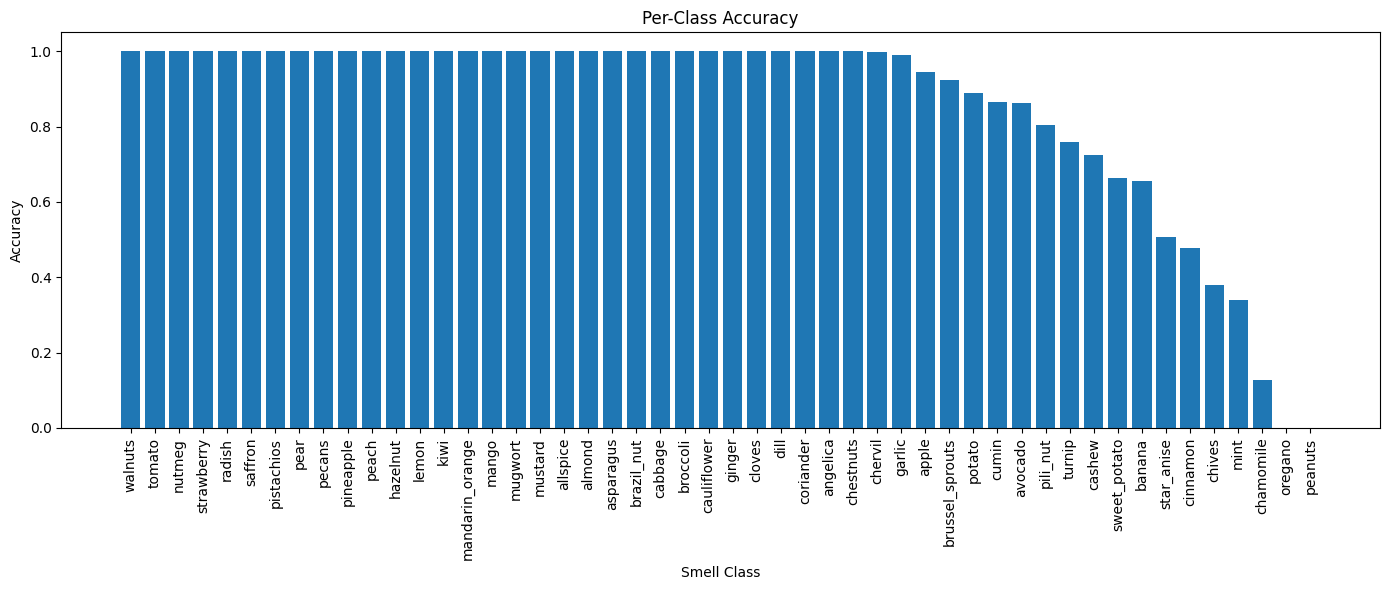

In [29]:
import matplotlib.pyplot as plt

sorted_idx = np.argsort(per_class_acc)[::-1]
sorted_acc = per_class_acc[sorted_idx]
sorted_names = class_names[sorted_idx]

plt.figure(figsize=(14,6))
plt.bar(sorted_names, sorted_acc)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.xlabel("Smell Class")
plt.title("Per-Class Accuracy")
plt.tight_layout()
plt.show()